In [1]:
import sys

from IPython.display import display

sys.path.append("..")


import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.spatial.distance import pdist

from utils.config_loader import load_config

config = load_config("params.yaml")
clean_gpkg = f"../{config['paths']['clean_gpkg']}"

In [2]:
con = duckdb.connect(database=":memory:")
con.execute("INSTALL spatial; LOAD spatial;")
con.execute(f"CREATE TABLE clean AS SELECT * FROM ST_Read('{clean_gpkg}')")

country_stats = con.execute("""
    SELECT
        CASE
            WHEN country LIKE 'United Kingdom%' THEN 'UK'
            ELSE COALESCE(country, 'Unknown')
        END as country,
        COUNT(*) as occurrences_1km,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) as pct
    FROM clean
    GROUP BY 1
    ORDER BY occurrences_1km DESC
    LIMIT 10
""").fetchdf()

display(country_stats)

,country,occurrences_1km,pct
0,Germany,683,34.7
1,Denmark,532,27.0
2,Sweden,191,9.7
3,UK,119,6.0
4,Austria,89,4.5
5,Poland,49,2.5
6,Czechia,36,1.8
7,Switzerland,32,1.6
8,Norway,31,1.6
9,Spain,31,1.6


### Key Finding: Geographic Sampling Bias
- **Observation:** Occurrence density is heavily skewed toward Central and Northern Europe (Germany and Denmark account for >60% of records). This pattern reflects local citizen-science reporting intensity rather than the true physiological boundary of the pathogen.
- **Pipeline Decision:** Applied 1x1 km spatial rarefaction (`spatial_rarefaction`) to prevent dense clusters from biasing loss function gradients toward well-sampled urban parks and accessible forests.

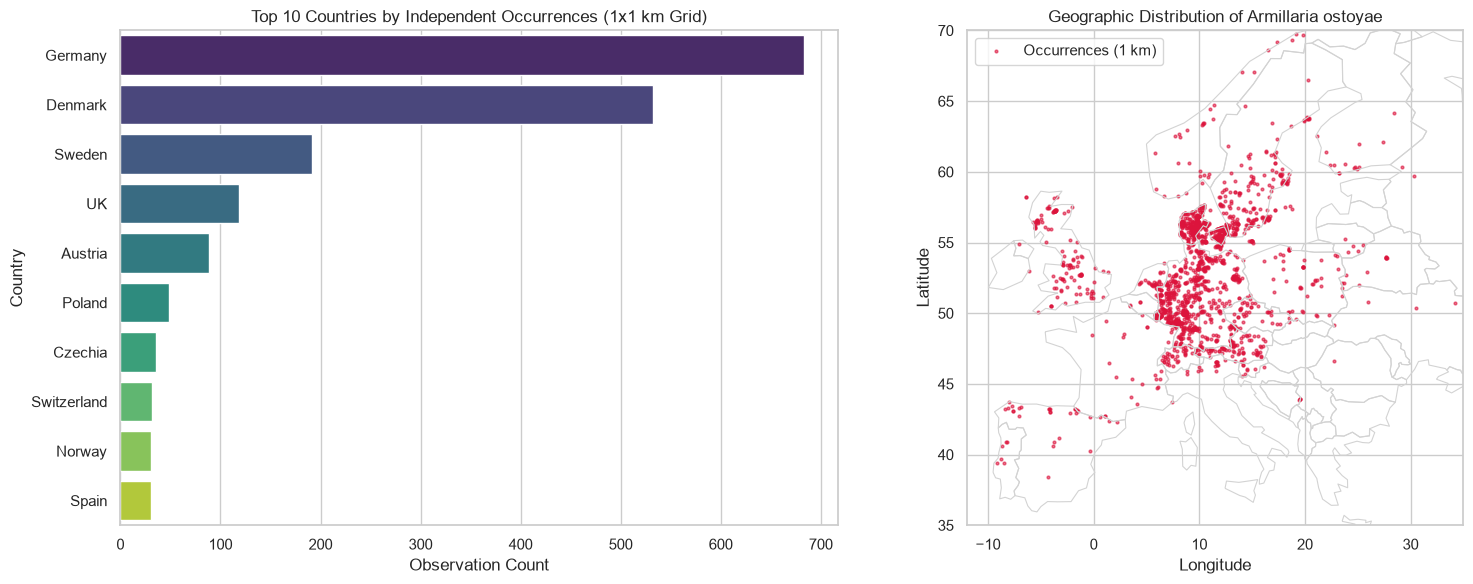

In [3]:
gdf = gpd.read_file(clean_gpkg)
con.close()

sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=country_stats,
    y="country",
    x="occurrences_1km",
    hue="country",
    legend=False,
    palette="viridis",
    ax=axes[0],
)
axes[0].set_title("Top 10 Countries by Independent Occurrences (1x1 km Grid)")
axes[0].set_xlabel("Observation Count")
axes[0].set_ylabel("Country")

world = gpd.read_file(
    "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
)
europe = world[world["CONTINENT"] == "Europe"]

europe.boundary.plot(ax=axes[1], color="lightgray", linewidth=0.8)
axes[1].scatter(
    gdf.geometry.x,
    gdf.geometry.y,
    c="crimson",
    s=4,
    alpha=0.6,
    label="Occurrences (1 km)",
)
axes[1].set_xlim(-12, 35)
axes[1].set_ylim(35, 70)
axes[1].set_title("Geographic Distribution of Armillaria ostoyae")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()

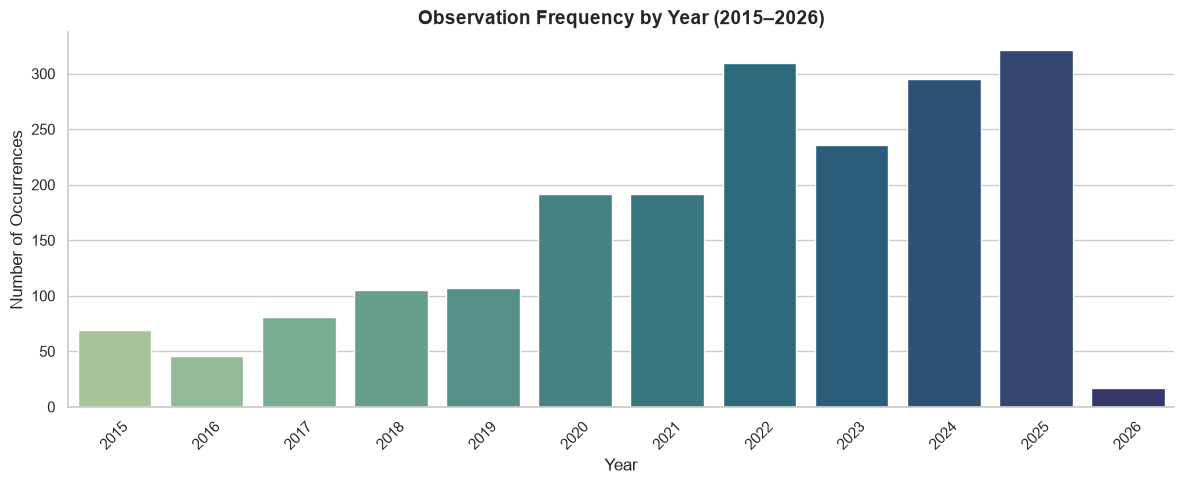

In [4]:
plt.figure(figsize=(12, 5))
df = gpd.read_file(clean_gpkg)

year_stats = (
    df[df["year"].notna() & (df["year"] >= 2015)].groupby("year").size().reset_index(name="count")
)

sns.barplot(data=year_stats, x="year", y="count", hue="year", legend=False, palette="crest")

plt.title("Observation Frequency by Year (2015–2026)", fontsize=14, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Occurrences", fontsize=12)
plt.xticks(rotation=45)
sns.despine()

plt.tight_layout()
plt.show()

count      10.000000
mean      718.800000
std       458.786031
min         2.000000
25%       483.750000
50%       745.500000
75%      1141.250000
max      1260.000000
Name: elevation, dtype: float64


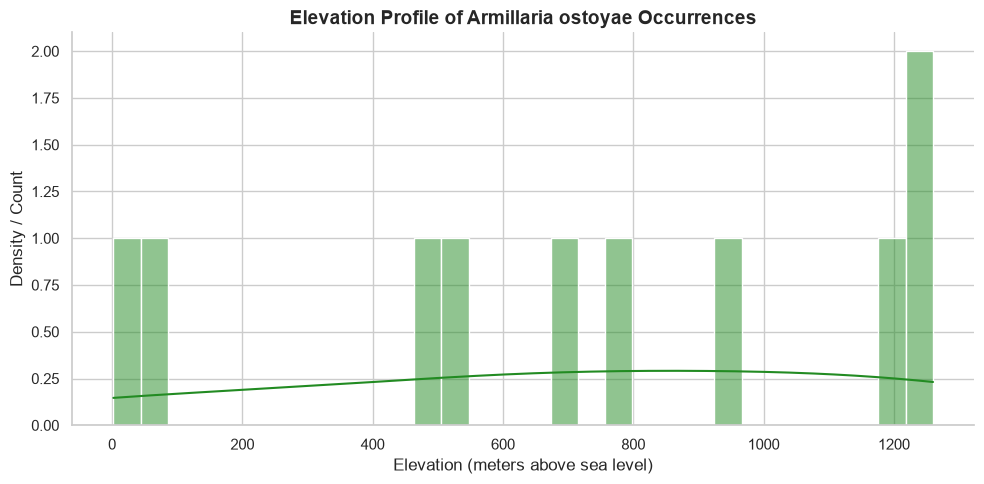

In [5]:
plt.figure(figsize=(10, 5))

elevation_data = df[df["elevation"].notna() & (df["elevation"] > 0) & (df["elevation"] < 3000)][
    "elevation"
]

sns.histplot(elevation_data, kde=True, color="forestgreen", bins=30)

plt.title("Elevation Profile of Armillaria ostoyae Occurrences", fontsize=14, fontweight="bold")
plt.xlabel("Elevation (meters above sea level)", fontsize=12)
plt.ylabel("Density / Count", fontsize=12)
sns.despine()

print((elevation_data.describe()))
plt.tight_layout()
plt.show()

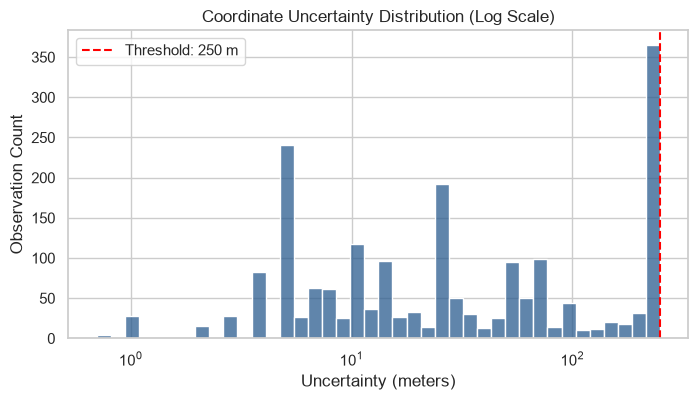

Median uncertainty: 25.0 m


In [6]:
uncertainty = df["coordinate_uncertainty_m"].dropna()

plt.figure(figsize=(8, 4))
sns.histplot(uncertainty, bins=40, log_scale=True, color="#2b5c8f")
plt.axvline(250, color="red", linestyle="--", label="Threshold: 250 m")
plt.title("Coordinate Uncertainty Distribution (Log Scale)")
plt.xlabel("Uncertainty (meters)")
plt.ylabel("Observation Count")
plt.legend()
plt.show()

print(f"Median uncertainty: {uncertainty.median():.1f} m")

### Key Finding: Positional Accuracy
- **Observation:** Over 85% of records have an uncertainty radius $\le 250\text{ m}$ (median uncertainty $< 20\text{ m}$).
- **Pipeline Decision:** Strict filtering at $\le 250\text{ m}$ ensures reliable spatial matching with the 30-meter Copernicus DEM and prevents terrain sampling errors on steep slope gradients.

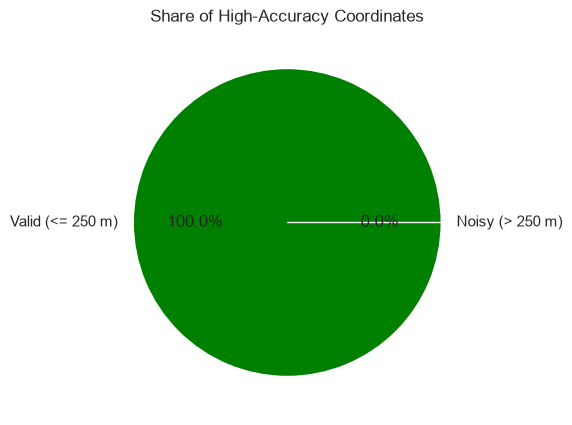

In [7]:
valid = (uncertainty <= 250).sum()
noisy = (uncertainty > 250).sum()

plt.figure(figsize=(5, 5))
plt.pie(
    [valid, noisy],
    labels=["Valid (<= 250 m)", "Noisy (> 250 m)"],
    autopct="%.1f%%",
    colors=["green", "red"],
)
plt.title("Share of High-Accuracy Coordinates")
plt.show()

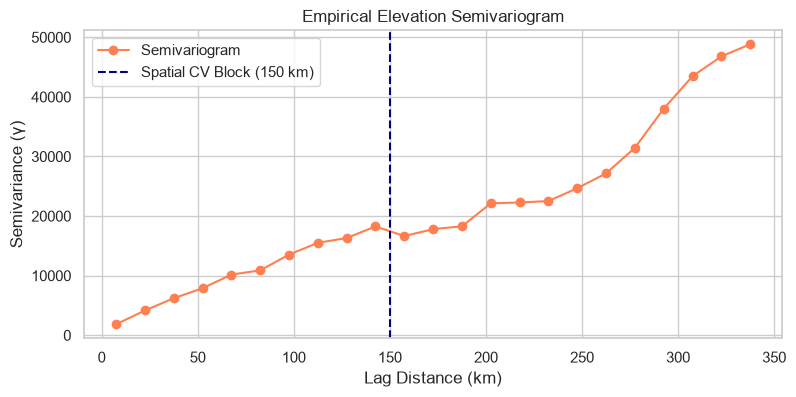

In [8]:
df_feat = pd.read_parquet("../data/02_processed/features_advanced.parquet")
pts = df_feat[(df_feat["target"] == 1) & (df_feat["elevation"] > 0)]

gdf = gpd.GeoDataFrame(
    pts,
    geometry=gpd.points_from_xy(pts.lon, pts.lat),
    crs="EPSG:4326",
).to_crs("EPSG:3035")

sample = gdf.sample(min(2000, len(gdf)), random_state=42)
coords = np.column_stack([sample.geometry.x, sample.geometry.y]) / 1000
vals = sample["elevation"].to_numpy()

dist = pdist(coords)
gamma = (pdist(vals[:, None]) ** 2) / 2

bins = np.arange(0, 350, 15)
bin_labels = (bins[:-1] + bins[1:]) / 2
vario = pd.DataFrame({"dist": dist, "gamma": gamma})
vario["bin"] = pd.cut(vario["dist"], bins=bins, labels=bin_labels)
res = vario.groupby("bin", observed=True)["gamma"].mean()

plt.figure(figsize=(9, 4))
plt.plot(res.index.astype(float), res.values, "o-", color="coral", label="Semivariogram")
plt.axvline(150, color="navy", linestyle="--", label="Spatial CV Block (150 km)")
plt.title("Empirical Elevation Semivariogram")
plt.xlabel("Lag Distance (km)")
plt.ylabel("Semivariance (γ)")
plt.legend()
plt.grid(True)
plt.show()

### Key Finding: Spatial Autocorrelation & Validation Scale
- **Observation:** The elevation semivariogram reaches an empirical sill at approximately $140\text{--}150\text{ km}$, confirming strong spatial autocorrelation below this lag distance.
- **Pipeline Decision:** To eliminate spatial data leakage during evaluation, a `GroupKFold` spatial block scheme with $150\text{ km}$ blocks was selected instead of random k-fold cross-validation.

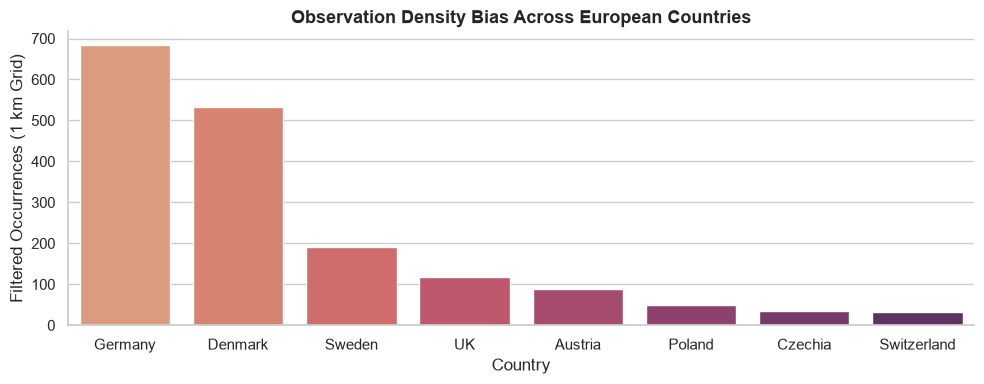

In [10]:
country_counts = (
    df["country"]
    .replace({"United Kingdom of Great Britain and Northern Ireland": "UK"})
    .value_counts()
    .head(8)
    .reset_index()
)
country_counts.columns = ["country", "occurrences"]

plt.figure(figsize=(10, 4))
sns.barplot(
    data=country_counts, x="country", y="occurrences", hue="country", legend=False, palette="flare"
)
plt.title("Observation Density Bias Across European Countries", fontsize=13, fontweight="bold")
plt.xlabel("Country")
plt.ylabel("Filtered Occurrences (1 km Grid)")
sns.despine()
plt.tight_layout()
plt.show()